In [1]:
import numpy as np
import pandas as pd
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
alpha = 0.05

bids_folder = '/Users/mrenke/data/ds-dnumrisk'
phenotype_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'

groupList =  pd.read_csv(op.join(bids_folder, 'group_mapping.csv'), header=0, index_col=0)
groupList['group'] = np.where(groupList['group'] == 0, 'Control', 'Dyscalculic')

from utils_statistics import between_group_comparison

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
iq_scores = pd.read_csv(op.join(phenotype_folder, 'iq-scores_ids2.csv')).set_index('subject')
math_stuff = pd.read_csv(op.join(phenotype_folder, 'math_skill&confidence&anxiety-means.csv')).set_index('subject')


In [ ]:
df_parietalDANpatch_size = pd.read_csv(op.join(phenotype_folder, 'netsPFM_DANpatches.csv'))
df_parietalDANpatch_size = df_parietalDANpatch_size.rename(columns={'sub_id':'subject'}).set_index(['subject','patch'])
area_measure = 'ind_area' #
df_parietalDANpatch_size = df_parietalDANpatch_size[area_measure].unstack('patch')
df_parietalDANpatch_size = df_parietalDANpatch_size/100 # convert to cm^2

#df_comb = df_parietalDANpatch_size.join(iq_scores).join(groupList).join(math_stuff['skill_score'])

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_75540/274365615.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='group',hue='group', y=y_var, data=tmp, ax=ax, alpha=0.5, ci='sd')
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_75540/274365615.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='group',hue='group', y=y_var, data=tmp, ax=ax, alpha=0.5, ci='sd')
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_75540/274365615.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='group',hue='group', y=y_var, data=tmp, ax=ax, alpha=0.5, ci='sd')
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_75540/274365615.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='group',hue='group', y=y_var, data=tmp,

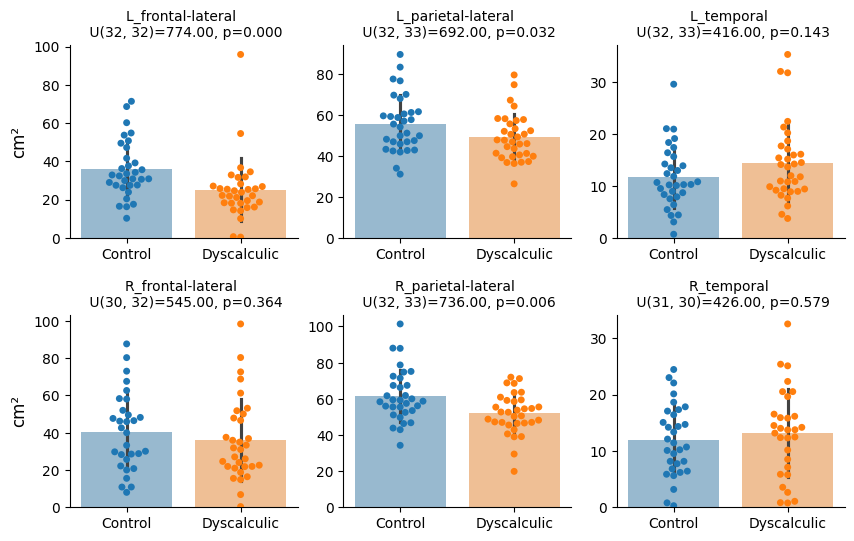

In [35]:
fig, axs = plt.subplots(2,3, figsize=(10,6))

tmp = df_parietalDANpatch_size.join(groupList)
for y_var, ax in zip(df_parietalDANpatch_size.columns, axs.flat):
    sns.barplot(x='group',hue='group', y=y_var, data=tmp, ax=ax, alpha=0.5, ci='sd')
    sns.swarmplot(x='group', hue='group', y=y_var, data=tmp, ax=ax)
    stats, stats_term = between_group_comparison(tmp, y_var)
    #name = y_var.split('_')[-1]
    ax.set_title(f'{y_var} \n {stats_term}={stats.statistic:.2f}, p={stats.pvalue:.3f}', size=10)
    ax.set(xlabel=None, ylabel=None)
    sns.despine(ax=ax)
axs.flat[0].set_ylabel('cm²', size=12)
axs.flat[3].set_ylabel('cm²',  size=12)

fig.subplots_adjust(hspace=0.4)

In [79]:
df_npc_grad_dispersion = pd.read_csv(op.join(phenotype_folder,'NPC_dispersion_2D_final.csv'))
df_npc_grad_dispersion = df_npc_grad_dispersion.set_index('subject').drop(columns=['group'])

df_npc_pfm_net_area = pd.read_csv(op.join(phenotype_folder,'netsPFM_indArea_NPC.csv'))
df_npc_pfm_net_area = df_npc_pfm_net_area.set_index(['subject','network']).unstack('network')
df_npc_pfm_net_area.columns = [(col[1] + '_' + col[0]) for col in df_npc_pfm_net_area.columns]


In [80]:
x_vars = ['NPC_dispersion', # df_npc_grad_dispersion
            'Dorsal-attention_size', 'Visual2_size', #df_npc_pfm_net_area
          'L_frontal-lateral','L_parietal-lateral',
          'R_frontal-lateral','R_parietal-lateral'] #df_parietalDANpatch_size
y_vars = ['skill_score', # math_stuff.columns
            'me', 'kn'] # iq_scores.columns

df_comb = df_parietalDANpatch_size.join(df_npc_pfm_net_area).join(df_npc_grad_dispersion).join(iq_scores).join(groupList).join(math_stuff['skill_score'])

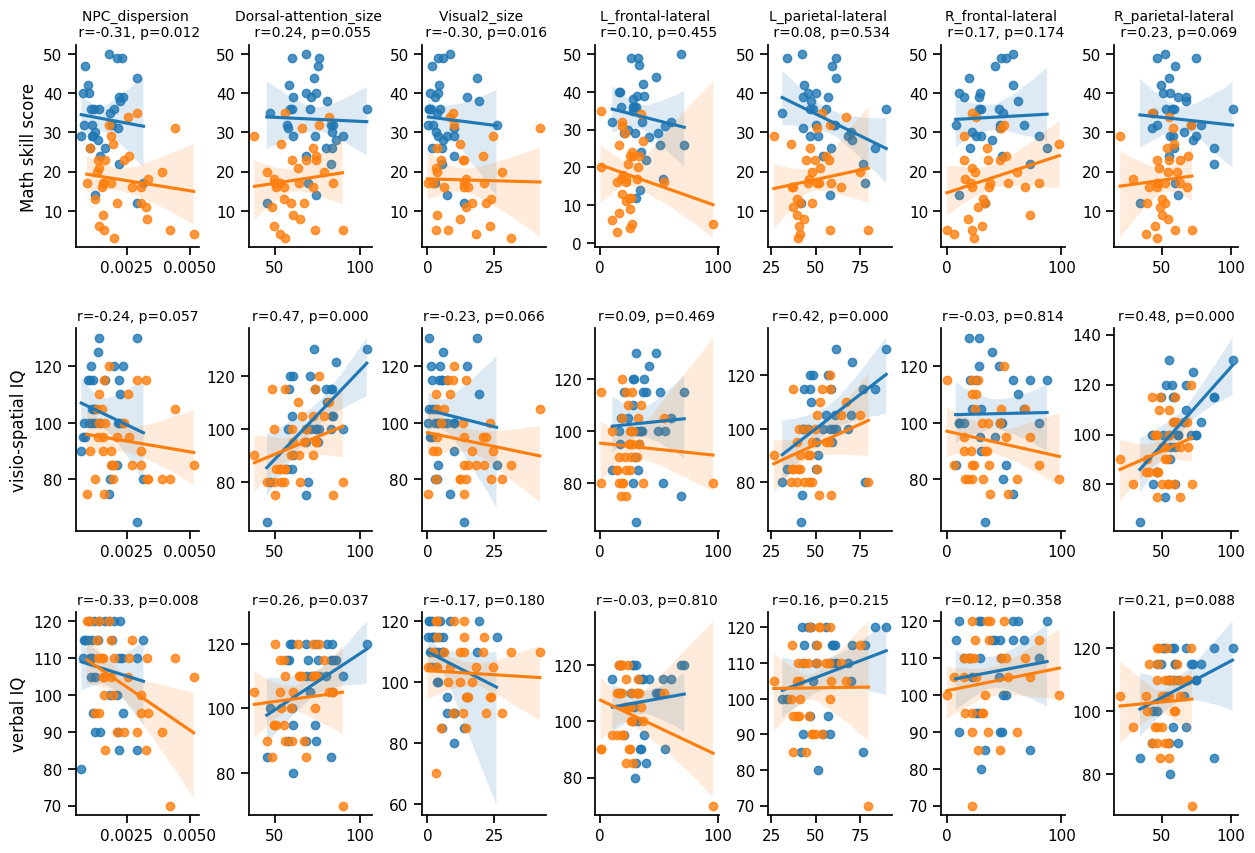

In [81]:
import pingouin

fig, axs = plt.subplots(3,len(x_vars), figsize=(15,10))
for j, y_var in enumerate(y_vars):
    for i, x_var in enumerate(x_vars):
        ax = axs[j, i]
        for k, group in enumerate(df_comb['group'].unique()):
            tmp = df_comb[df_comb['group'] == group]
            sns.regplot(x=x_var, y=y_var, data=tmp, color=sns.color_palette()[k], ax=ax)

        cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'pearson') #defautl: two -sided & pearson
        r_coeff = cor['r'].iloc[0]
        pval = cor['p-val'].iloc[0]
        #print(f'{x_var} vs {y_var}: r={r_coeff}, p= {pval}')
        if j == 0:
            ax.set_title(f'{x_var} \n r={r_coeff:.2f}, p={pval:.3f}', size=10)
        else:
            ax.set_title(f'r={r_coeff:.2f}, p={pval:.3f}', size=10)

        ax.set(xlabel=None, ylabel=None)
        sns.despine()

axs[0,0].set_ylabel('Math skill score', size=12)
axs[1,0].set_ylabel('visio-spatial IQ', size=12)
axs[2,0].set_ylabel('verbal IQ', size=12)
fig.subplots_adjust(hspace=0.4, wspace=0.4) 

R_parietal-lateral vs me: r=0.483294908462807, p= 4.5437661431093224e-05
R_parietal-lateral vs kn: r=0.21300719294554407, p= 0.08845417512339575
R_parietal-lateral vs skill_score: r=0.22673881219453795, p= 0.06932558579983059


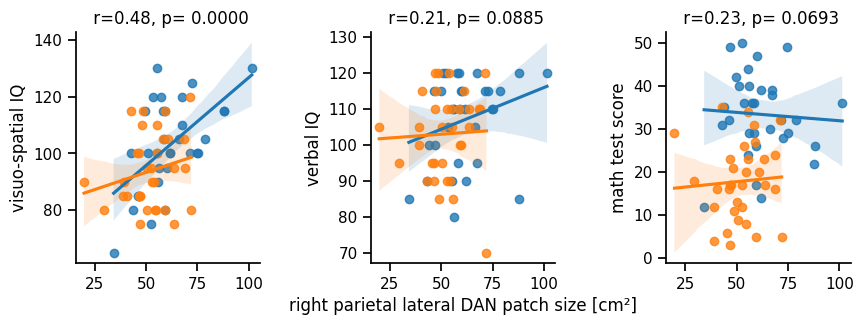

In [64]:
import pingouin

sns.set_context('notebook')

tmp = df_comb.copy()
x_var = 'R_parietal-lateral' #'Visual2_size' # 'Dorsal-attention_size' 
y_vars = ['me', 'kn', 'skill_score'] # iq_scores.columns
y_var_names = ['visuo-spatial IQ', 'verbal IQ', 'math test score']

fig, axs = plt.subplots(1,3, figsize=(10,3))
for i, y_var in enumerate(y_vars):
    cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'pearson') #defautl: two -sided & pearson
    r_coeff = cor['r'].iloc[0]
    pval = cor['p-val'].iloc[0]
    print(f'{x_var} vs {y_var}: r={r_coeff}, p= {pval}')

    for j, group in enumerate(df_comb['group'].unique()):
        tmp = df_comb[df_comb['group'] == group]
        sns.regplot(x=x_var, y=y_var, data=tmp, color=sns.color_palette()[j], ax=axs[i])

    axs[i].set(title=f' r={r_coeff:.2f}, p= {pval:.4f}', ylabel = y_var_names[i], xlabel=None)

axs[1].set(xlabel='right parietal lateral DAN patch size [cm²]')
fig.subplots_adjust(wspace=0.6)
sns.despine()
net_name = x_var #.split('_')[0]
#fig.suptitle(f'Correlations: IQ screener ~ {net_name}-network size in NPC', y = 1.1)

In [69]:
x_var = 'R_parietal-lateral' #'Visual2_size' # 'Dorsal-attention_size' 

for group in df_comb['group'].unique():
    print(f'Group: {group}')
    tmp = df_comb[df_comb['group'] == group]

    for i, y_var in enumerate(['me', 'kn', 'mean_iq']):
        cor = pingouin.corr(tmp[y_var], tmp[x_var], method = 'pearson') #defautl: two -sided & pearson
        r_coeff = cor['r'].iloc[0]
        pval = cor['p-val'].iloc[0]
        print(f'{x_var} vs {y_var}: r={r_coeff:.2f}, p= {pval:.3f}')

Group: Control
R_parietal-lateral vs me: r=0.56, p= 0.001
R_parietal-lateral vs kn: r=0.27, p= 0.132
R_parietal-lateral vs mean_iq: r=0.55, p= 0.001
Group: Dyscalculic
R_parietal-lateral vs me: r=0.21, p= 0.232
R_parietal-lateral vs kn: r=0.04, p= 0.827
R_parietal-lateral vs mean_iq: r=0.18, p= 0.318


In [65]:
x_var = 'L_parietal-lateral' #'Visual2_size' # 'Dorsal-attention_size' 
y_vars = ['me', 'kn', 'skill_score'] # iq_scores.columns
y_var_names = ['visuo-spatial IQ', 'verbal IQ', 'math test score']

for i, y_var in enumerate(['me', 'kn', 'mean_iq']):
    cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'pearson') #defautl: two -sided & pearson
    r_coeff = cor['r'].iloc[0]
    pval = cor['p-val'].iloc[0]
    print(f'{x_var} vs {y_var}: r={r_coeff:.2f}, p= {pval:.3f}')

L_parietal-lateral vs me: r=0.42, p= 0.000
L_parietal-lateral vs kn: r=0.16, p= 0.215
L_parietal-lateral vs mean_iq: r=0.39, p= 0.001


In [66]:
x_var = 'Dorsal-attention_size' #'Visual2_size' # 'Dorsal-attention_size' 

for i, y_var in enumerate(['me', 'kn', 'mean_iq']):
    cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'pearson') #defautl: two -sided & pearson
    r_coeff = cor['r'].iloc[0]
    pval = cor['p-val'].iloc[0]
    print(f'{x_var} vs {y_var}: r={r_coeff:.2f}, p= {pval:.3f}')

Dorsal-attention_size vs me: r=0.47, p= 0.000
Dorsal-attention_size vs kn: r=0.26, p= 0.037
Dorsal-attention_size vs mean_iq: r=0.49, p= 0.000


In [68]:
import statsmodels.api as sm

df_comb['R_par_lat'] = df_comb['R_parietal-lateral'] 

formula = f'R_par_lat ~  group + me'

result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              R_par_lat   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     12.14
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.56e-05
Time:                        15:14:50   Log-Likelihood:                -251.25
No. Observations:                  65   AIC:                             508.5
Df Residuals:                      62   BIC:                             515.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               22.9622     10.784      2.129      0.037       1.406      44.519
group[T.Dyscalculic]    -6.2584      3.081     -2.031      0.047     -12.418      -0.099
me                       0.3752      0.103      3.652      0.001       0.170       0.581
==============================================================================
Omnibus:                        0.982   Durbin-Watson:                   2.218
Prob(Omnibus):                  0.612   Jarque-Bera (JB):                0.630
Skew:                           0.238   Prob(JB):                        0.730
Kurtosis:                       3.073   Cond. No.                         737.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""